In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [54]:
df=pd.read_csv('CustomerChurn.csv')

In [55]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
df.shape

(7043, 21)

In [57]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [59]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [60]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [61]:
(df['Churn'].value_counts()*100)/df.shape[0]

,count
Churn,
No,73.463013
Yes,26.536987


Text(0.5, 1.0, 'Count of people churned')

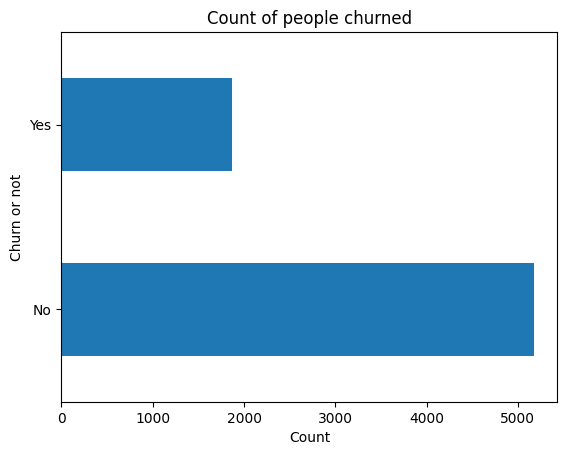

In [62]:
df['Churn'].value_counts().plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Churn or not')
plt.title('Count of people churned')

Text(0.5, 1.0, 'Missing Values per columns')

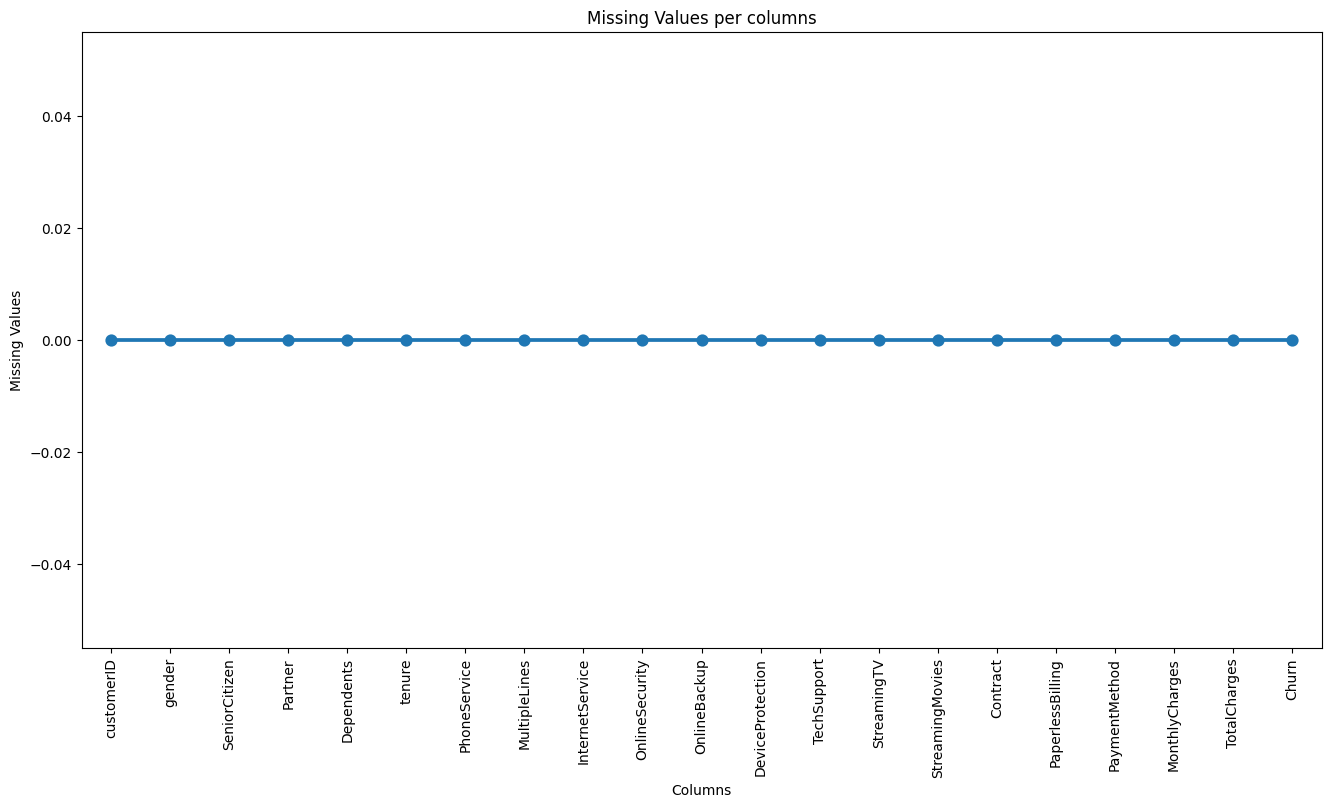

In [63]:
missing=(df.isnull().sum()*100/len(df)).reset_index()
plt.figure(figsize=(16,8))
sns.pointplot(data=missing, x='index', y=0)
plt.xticks(rotation=90)
plt.xlabel('Columns')
plt.ylabel('Missing Values')
plt.title('Missing Values per columns')


# **DATA CLEANING**

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [65]:
# total charges should be float
new_df=df.copy()

In [66]:
new_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
new_df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [68]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [69]:
new_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


if we calculate % of null values in total charges its 0.15 % which is very minimal so we can drop those roles directly

In [70]:
new_df.dropna(inplace=True)

In [71]:
new_df.shape

(7032, 21)

Okay. Okay, so there is a requirement of making binning in tenure section because tenure segment is continuous value. So for every value creating a bar plot is not suitable. So what we have to do is we have to group them together in bins and then evaluate or analyze the trend.

In [72]:
new_df['tenure'].max()


72

In [73]:
new_df['tenure'].min()


1

In [74]:
labels=['1-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80']
bins=[0,10,20,30,40,50,60,70,80]
new_df['Tenure_group']=pd.cut(new_df['tenure'],bins=bins,labels=labels)
new_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-10
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,31-40
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-10
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,41-50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,21-30
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,71-80
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,11-20
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1-10


In [75]:
new_df['Tenure_group'].value_counts()

,count
Tenure_group,
1-10,1959
11-20,908
61-70,875
21-30,763
51-60,698
41-50,652
31-40,645
71-80,532


So customer ID is not required as well as tenure is not required for further analysis, cleaning part is done. Tenure is not required because we have already created tenure groups.

In [76]:
new_df.drop(columns=['customerID','tenure'],inplace=True)

In [77]:
new_df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-10
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,31-40
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-10
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,41-50
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,21-30
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,71-80
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,11-20
7041,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1-10


# **DATA EXPLORATION**

In [78]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-10
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,31-40
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-10
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,41-50
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-10


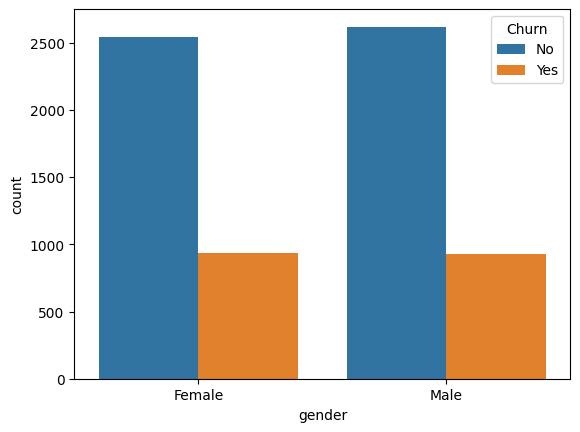

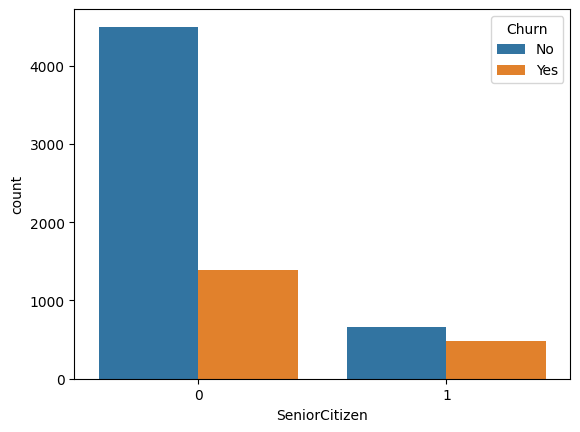

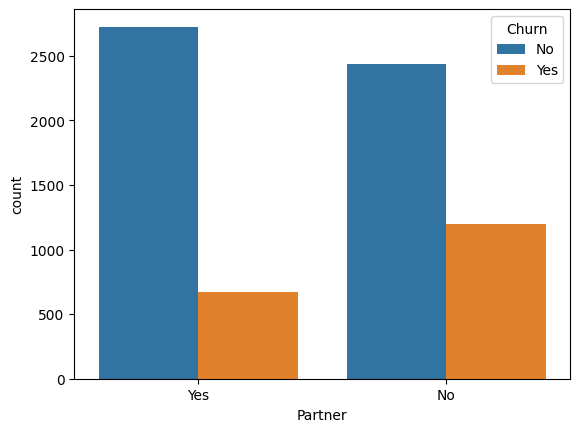

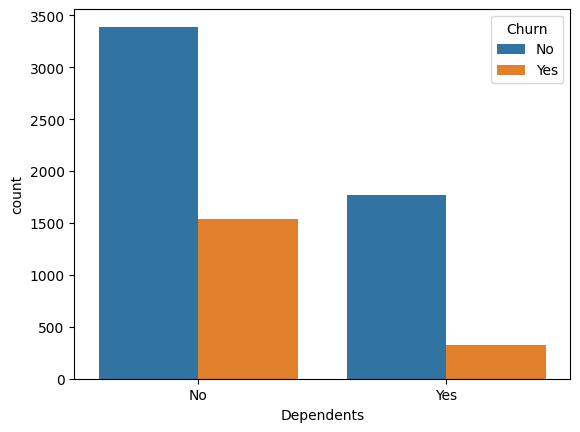

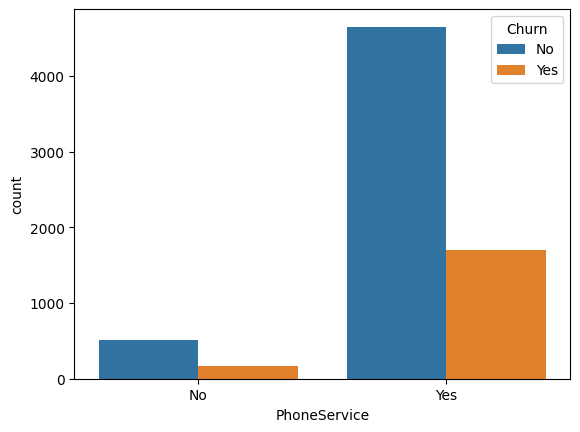

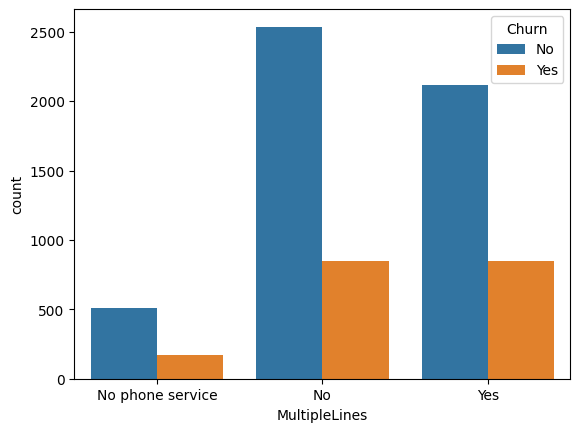

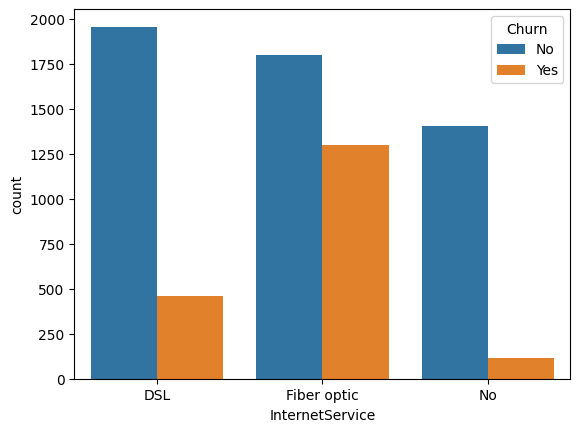

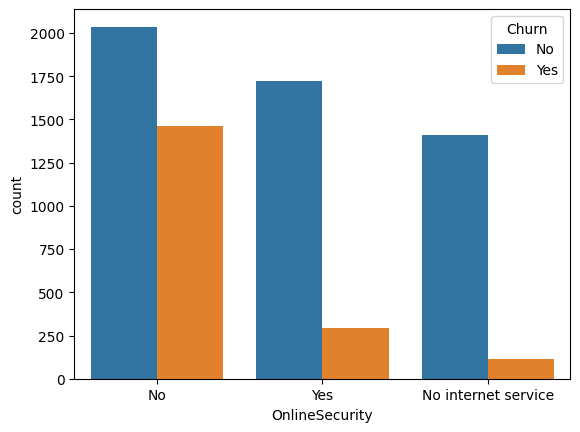

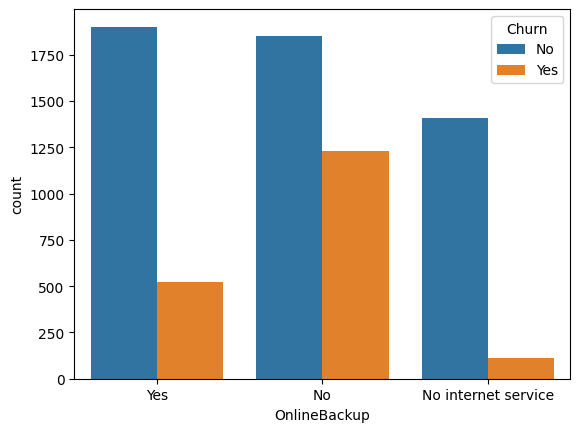

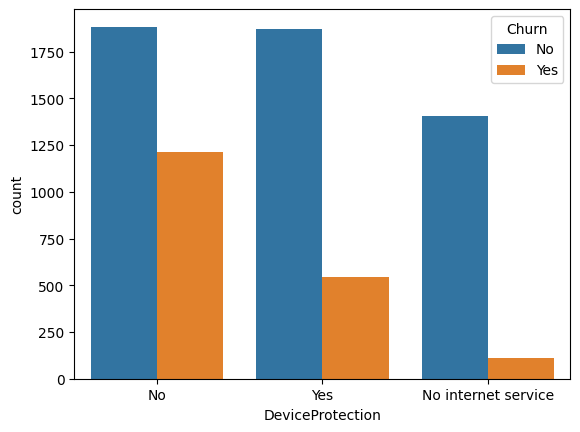

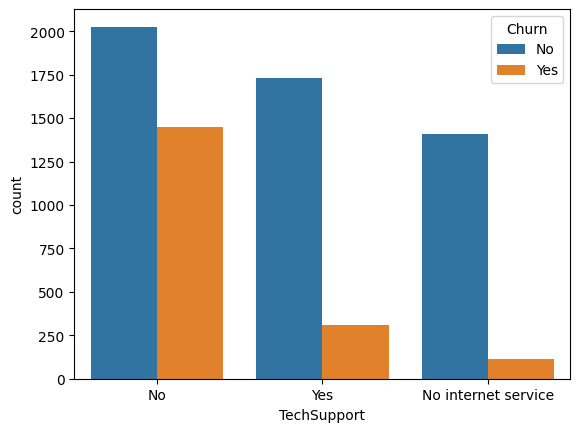

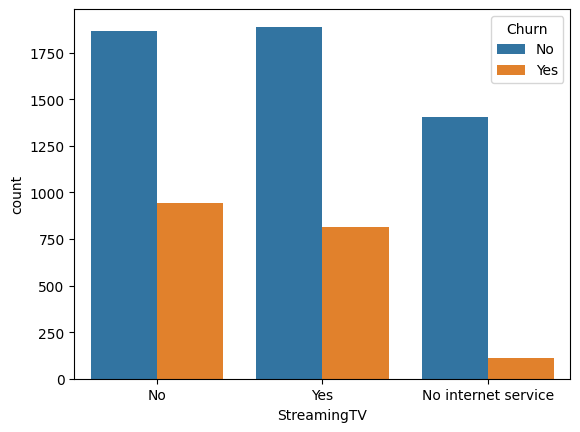

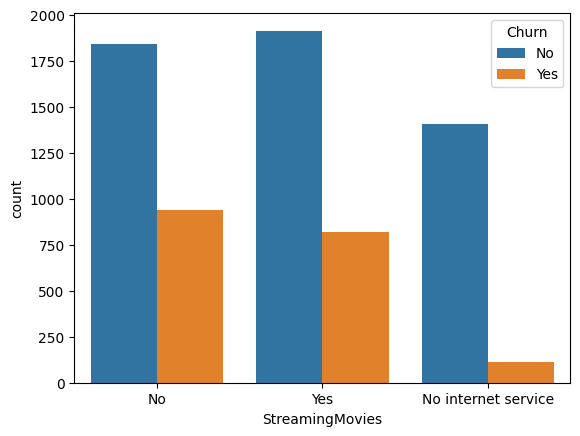

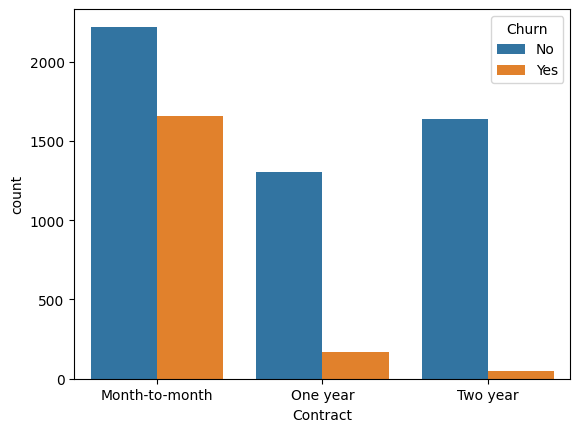

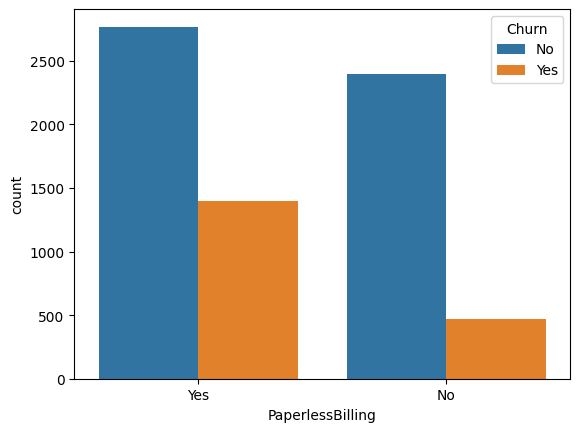

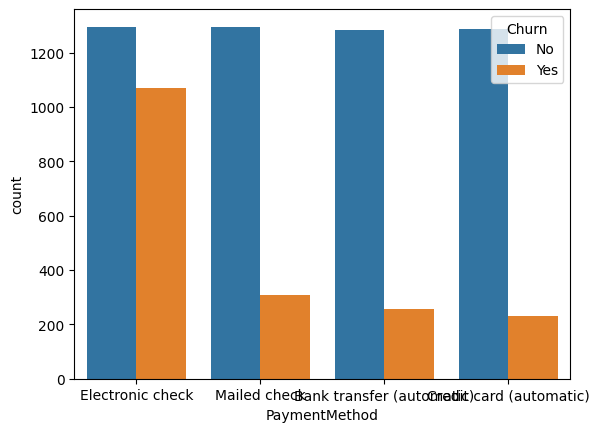

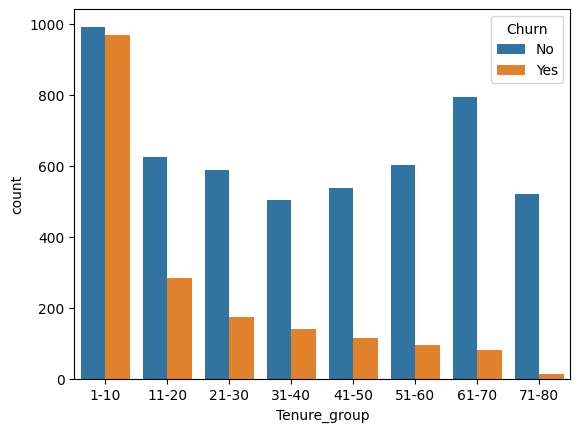

In [79]:
for el in new_df.drop(columns=['TotalCharges','MonthlyCharges','Churn']).columns:
  sns.countplot(x=new_df[el],hue=new_df['Churn'])
  plt.show()
  print()

In [80]:
(new_df['Churn'].value_counts()*100)/len(new_df)

,count
Churn,
No,73.421502
Yes,26.578498


From all the graphs we can draw insight:
1. Senior citizen are more likely to churn
2. People with no partners are more likely to churn
3. Montly contracts are more likely to churn because they are bound in lesser duration contract
4. People who pay via Electoric tends to churn more

NUMERICAL ANALYSIS

In [81]:
new_df['gender'].value_counts()

,count
gender,
Male,3549
Female,3483


now we will create 2 seperate df for churned customers and non churned ones

In [82]:
churned_df=new_df[new_df['Churn']=='Yes']

In [83]:
non_churned_df=new_df[new_df['Churn']=='No']

In [84]:
non_churned_df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-10
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,31-40
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,41-50
6,Male,0,No,Yes,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,21-30
7,Female,0,No,No,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,1-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,71-80
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,21-30
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,71-80
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,11-20


In [85]:
#gender ration in churned df
churned_df['gender'].value_counts()

,count
gender,
Female,939
Male,930


In [86]:
new_df['gender'].value_counts()
# in orignal as well as in churned ones the ratio of gender is 1 : 1 almost which isn't significant

,count
gender,
Male,3549
Female,3483


In [87]:
pd.crosstab(new_df['PaymentMethod'],new_df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


Convert the target variable into numeric one yes=1 no=0

In [88]:
new_df['Churn']=np.where(new_df['Churn']=='Yes',1,0)

In [89]:
new_df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-10
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,31-40
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-10
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,41-50
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,21-30
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,71-80
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,11-20
7041,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,1-10


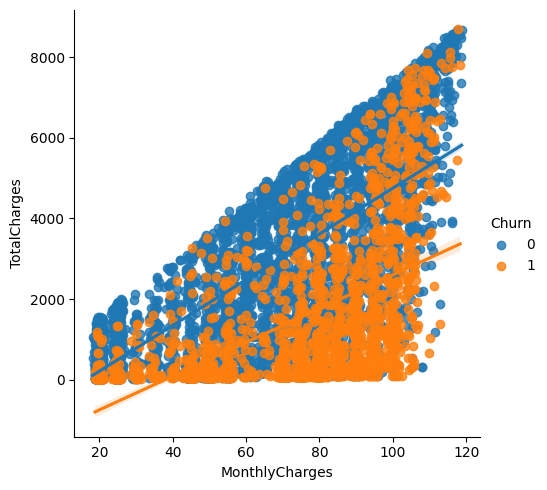

In [90]:
sns.lmplot(data=new_df,x='MonthlyCharges',y='TotalCharges',hue='Churn')

Insight - Churn tends to be higher when Monthly Charges are high but Total Charges are low. Since Total Charges accumulate over tenure, this pattern reflects customers who join on premium/expensive plans (e.g., fiber optic) but leave early — before their cumulative spend has a chance to grow. This is consistent with the earlier finding that low-tenure customers are the most likely to churn.



In [91]:
new_df['MonthlyCharges'].corr(new_df['TotalCharges'])

np.float64(0.6510648032262027)

Total charges increase as montly charges increase - as expected

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

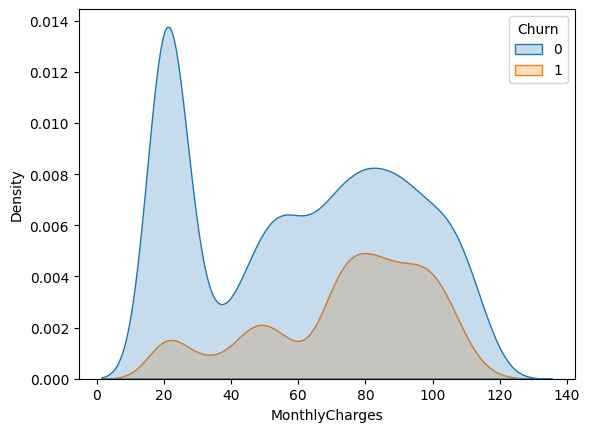

In [92]:
sns.kdeplot(x=new_df['MonthlyCharges'],hue=new_df['Churn'],fill=True)

insight - churning is high when monthly charges are observed to be high

<Axes: xlabel='TotalCharges', ylabel='Density'>

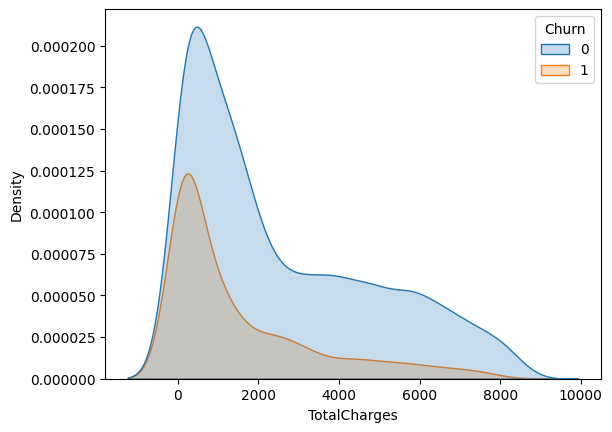

In [93]:
sns.kdeplot(x=new_df['TotalCharges'],hue=new_df['Churn'],fill=True)

**insight - churn is high when total charge is low**

In [94]:
new_df.corr(numeric_only=True)['Churn']

,Churn
SeniorCitizen,0.150541
MonthlyCharges,0.192858
TotalCharges,-0.199484
Churn,1.000000


In [95]:
new_df_dummies=pd.get_dummies(new_df)
new_df_dummies

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_group_1-10,Tenure_group_11-20,Tenure_group_21-30,Tenure_group_31-40,Tenure_group_41-50,Tenure_group_51-60,Tenure_group_61-70,Tenure_group_71-80
0,0,29.85,29.85,0,True,False,False,True,True,False,...,True,False,True,False,False,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,True,True,False,False,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,True,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,84.80,1990.50,0,False,True,False,True,False,True,...,False,True,False,False,True,False,False,False,False,False
7039,0,103.20,7362.90,0,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
7040,0,29.60,346.45,0,True,False,False,True,False,True,...,True,False,False,True,False,False,False,False,False,False
7041,1,74.40,306.60,1,False,True,False,True,True,False,...,False,True,True,False,False,False,False,False,False,False


<Axes: >

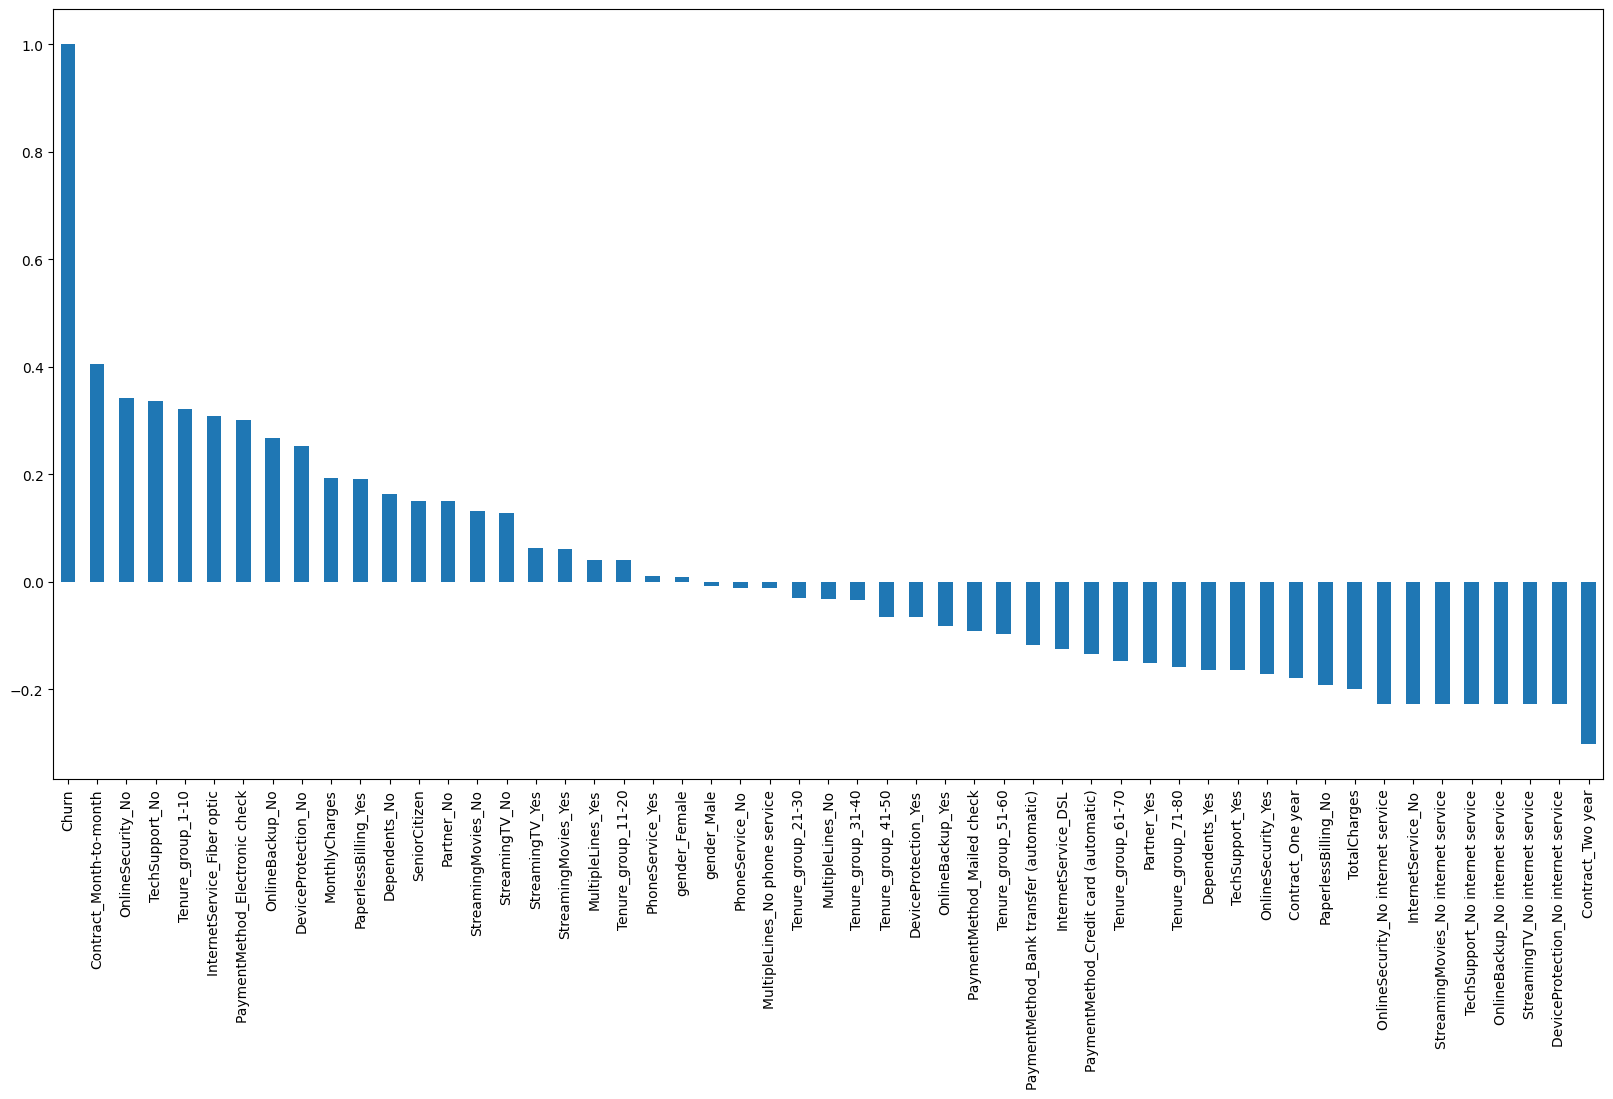

In [96]:
plt.figure(figsize=(20,10))
new_df_dummies.corr(numeric_only=True)['Churn'].sort_values(ascending=False).plot(kind='bar')

new insight
- people who don't have online security are likely to churn
- people who don't have tech support are likely to churn
- ....
- contract 2 yr low churner
-...

# Derived Insights Uptill Now
High churn is seen in case of Month to Month Contracts,no online security,no tech support, first year of subscription and fibre optics internet

Low churn is seen in case of long term contracts, subscription without internet service and customer engaged for 5+ yrs

Factors like gender, availability of phone service and multiple lines have almonst no impact on churn

This is also evident from heatmap below


<Axes: >

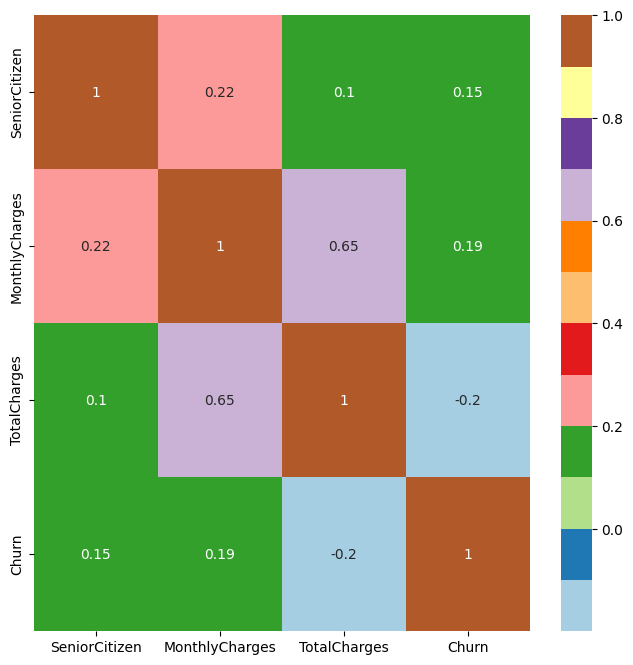

In [97]:
plt.figure(figsize=(8,8))
sns.heatmap(new_df.corr(numeric_only=True),annot=True,cmap='Paired')

<Axes: xlabel='tenure', ylabel='Density'>

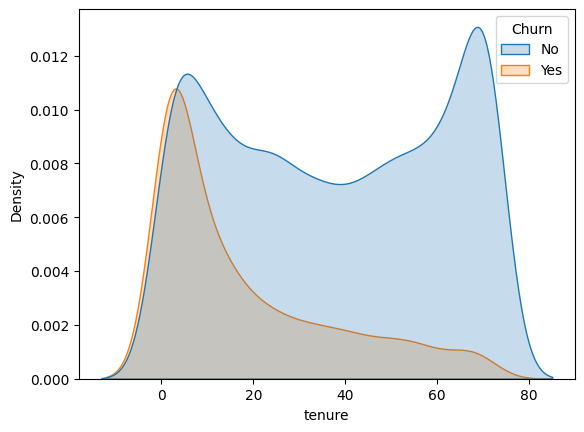

In [98]:
sns.kdeplot(x=df['tenure'],hue=df['Churn'],fill=True)

less tenure.. people who are new are high churners

## **BIVARIATE ANALYSIS**

In [99]:
churned_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-10
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-10
5,Female,0,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1-10
8,Female,0,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,21-30
13,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,41-50


In [100]:
 non_churned_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-10
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,31-40
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,41-50
6,Male,0,No,Yes,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,21-30
7,Female,0,No,No,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,1-10


<Axes: title={'center': 'Distribution of Genders for Churned Customers'}, xlabel='Partner', ylabel='count'>

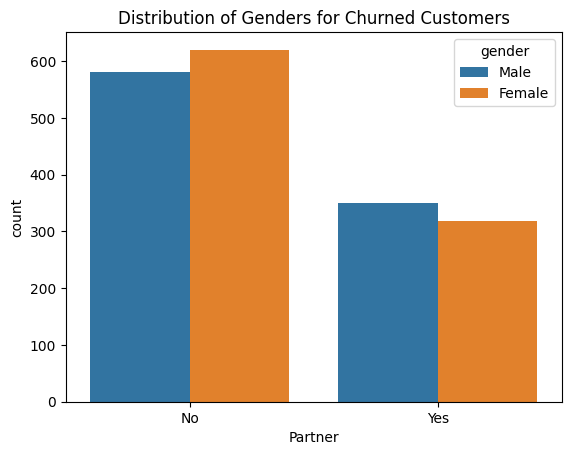

In [101]:
plt.title('Distribution of Genders for Churned Customers')
sns.countplot(x=churned_df['Partner'],hue=churned_df['gender'])

insight - Intially we knew that people with no partners are likely to churn but know we know that amongst the no partners females are likely to churn

"Among churned customers, those without a partner constitute a larger proportion than those with a partner. In the customers without a partner, females are slightly higher in number, whereas among customers with a partner, males are slightly higher."

<Axes: title={'center': 'Distribution of Genders for Churned Customers'}, xlabel='PaymentMethod', ylabel='count'>

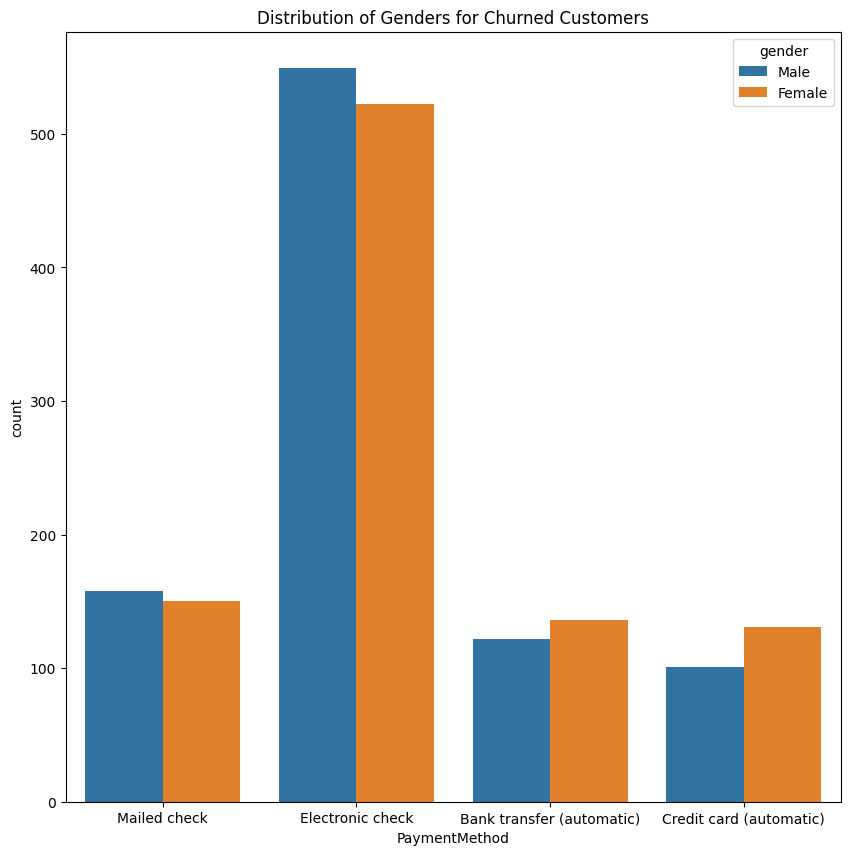

In [102]:
plt.figure(figsize=(10,10))
plt.title('Distribution of Genders for Churned Customers')
sns.countplot(x=churned_df['PaymentMethod'],hue=churned_df['gender'])

insight -
1) uptill now we knew that amongst the payment methods Electronic Check tends to witness more churning but from the above we get to know that within people preferring electronic check males are the more churner


<Axes: title={'center': 'Distribution of Genders for Churned Customers'}, xlabel='Contract', ylabel='count'>

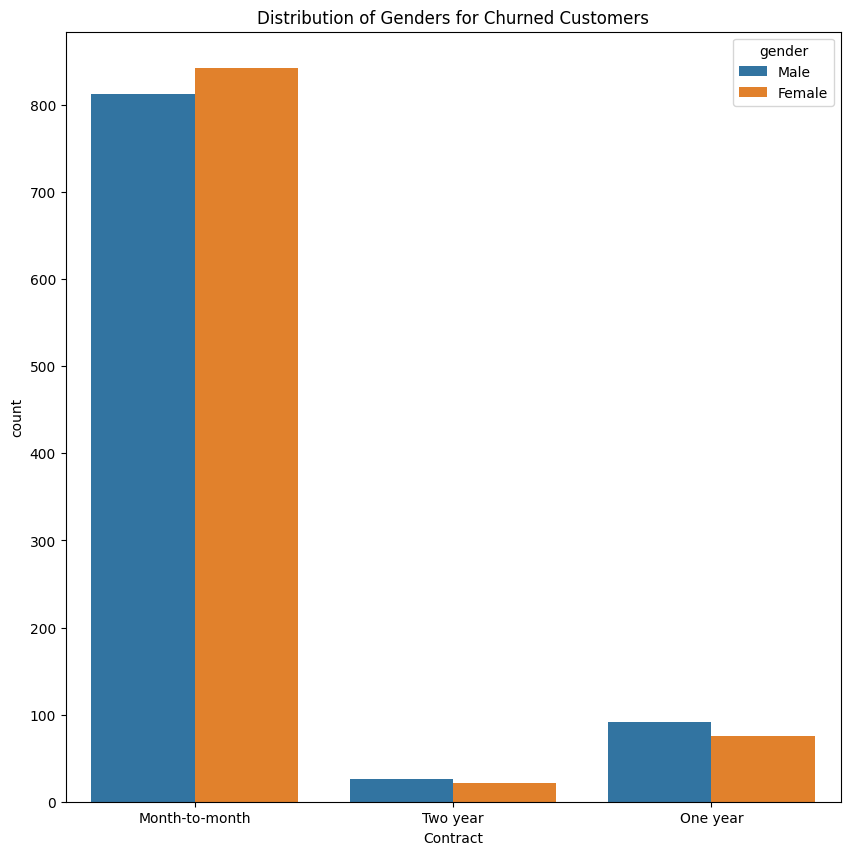

In [103]:
plt.figure(figsize=(10,10))
plt.title('Distribution of Genders for Churned Customers')
sns.countplot(x=churned_df['Contract'],hue=churned_df['gender'])

No significant insight from above graph

# **Conclusion**

This EDA was performed on the Telco Customer Churn dataset (7,043 customers, 21 features) to understand the key drivers behind customer attrition. After cleaning (dropping 11 rows with missing TotalCharges, converting it to numeric, and binning tenure into groups), the overall churn rate was found to be 26.58%, indicating a significant retention problem.

Key factors associated with higher churn:

1) Contract type is the strongest driver — customers on month-to-month contracts churn far more than those on one- or two-year contracts, since they face no penalty for leaving.
2) Tenure has a strong inverse relationship with churn — customers in their first year are the most likely to leave, while those with 5+ years of tenure rarely churn.
3) Customers without Online Security or without Tech Support show noticeably higher churn.
4) Fiber optic internet users churn more than DSL or no-internet users.
5) Senior citizens churn at a higher rate than non-seniors.
6) Customers without a partner churn more than those with a partner; within this group, females churn slightly more, while among customers with a partner, males churn slightly more.
7) Electronic check is the payment method most associated with churn, and within this group, males show higher churn than females.
8) Churn tends to be higher when Monthly Charges are high but Total Charges are low, suggesting that high-paying customers who churn tend to leave early, before accumulating spend.(Total charges = Monthly Charges X tenure)

Key factors associated with lower/no impact on churn:

1) Long-term contracts (especially 2-year), high tenure (5+ years), and no internet service are associated with the lowest churn.
2) Gender, phone service, and multiple lines show almost no relationship with churn and can largely be ruled out as drivers.